# Project 1 on Machine Learning: regression analysis, resampling methods and gradient descent

**Data Analysis and Machine Learning FYS-STK3155/FYS4155, University of Oslo, fall 2026**

**Deadline: October 5 (midnight), 2026.** Published August 31, 2026.

This notebook is the Jupyter version of the project text (`Project1.pdf`). The
code cells are *starting points*, not solutions: they set up the data and show
the automatic-differentiation check asked for in part e). Everything else is
yours to write.

## Preamble: note on writing reports, using reference material, AI and other tools

We want you to answer the three different projects by handing in reports
written like a standard scientific/technical report. The links at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/Projects>
contain more information. There you can find examples of previous reports, the
projects themselves, how we grade reports etc. How to write reports will also be
discussed during the various lab sessions. Please do ask us if you are in doubt.
In that folder you will find how we evaluate the projects. You will receive a
feedback with a final score for each project.

When using codes and material from other sources, you should refer to these in
the bibliography of your report, indicating wherefrom you for example got the
code, whether this is from the lecture notes, software like **Scikit-Learn**,
**JAX**, **TensorFlow**, **PyTorch** or other sources. These sources should
always be cited correctly. How to cite some of the libraries is often indicated
from their corresponding GitHub sites or websites; see for example how to cite
Scikit-Learn at <https://scikit-learn.org/dev/about.html>.

We encourage you to use Large Language models (LLMs) like
[ChatGPT](https://openai.com/chatgpt/), [Claude](https://claude.ai) or similar
in writing the report and in developing your code. In the report, you should
after the conclusions, write a declaration on how you have used LLMs following
the instructions at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/blob/main/LLM_Usage_Declaration_Guidelines.md>.
Failing to do so, <u>leads to an automatic deduction of five (5) points out of
the final score of 100 for the project</u>. Remember that *you* are responsible
for every line of code and every claim in the report: be prepared to explain and
defend all of it. If you use LLMs, please take a look at the guidelines at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/UsingLLMs>
on how to use these tools efficiently.

If you would like to study other data sets, feel free to propose other sets.
What we have proposed here are mere suggestions from our side. If you opt for
another data set, consider using a set which has been studied in the scientific
literature. This makes it easier for you to compare and analyze your results.
Comparing with existing results from the scientific literature is also an
essential element of the scientific discussion. The University of California at
Irvine with its Machine Learning repository at
<https://archive.ics.uci.edu/ml/index.php> is an excellent site to look up for
examples and inspiration. [Kaggle.com](https://www.kaggle.com/) is an equally
interesting site. Feel free to explore these sites and/or ask us for inputs
relevant to your discipline. When selecting other data sets, make sure these
are sets used for regression problems (not classification).

## Regression analysis, resampling methods and gradient descent

The main aim of this project is to study in more dgammail various regression
methods, including Ordinary Least Squares (OLS) regression, Ridge regression and
Lasso regression, together with the two resampling techniques (the bootstrap and
cross-validation) that let us assess and select models, and the gradient descent
methods that will be our optimizers for the rest of the course. In addition to
the scientific part, in this course we want also to give you an experience in
writing scientific reports.

We will study how to fit polynomials to a specific one-dimensional function
(feel free to replace the suggested function with more complicated ones). We
will use Runge's function (see
<https://en.wikipedia.org/wiki/Runge%27s_phenomenon> for a discussion),

$$
f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1].
$$

The project is organized so that it follows the weekly exercises and lectures of
the first weeks of the course:

- **Parts a) and b):** OLS and Ridge regression with closed-form solutions
  (weeks 34–36; the exercise sets of weeks 35 and 36 can be reused directly).
- **Parts c) and d):** the bias-variance tradeoff studied with the bootstrap,
  and cross-validation (week 36; Chapter 2, Sections 2.9–2.12 of the lecture
  notes).
- **Parts e) and f):** replacing the closed-form solutions by gradient descent,
  with gradients computed both analytically and by automatic differentiation,
  and with momentum and adaptive learning rates (weeks 37–38; Chapter 4).
- **Parts g) and h):** Lasso regression, our first method without a closed-form
  solution, and stochastic gradient descent (Chapter 4 of the lecture notes).
- **Part i):** the final comparison of OLS, Ridge and Lasso using
  cross-validation.

The analytical parts (in particular the derivation of the bias-variance
decomposition in part c) belong in the theory section of your report.
The material for solving the various exercises is covered by Chapters 2–4 of
the lecture notes and the lecture material for weeks 34–38.

### Setting up the data

A starting point: Runge's function on $[-1,1]$ with additive Gaussian noise,
and a polynomial design matrix. Feel free to change everything.

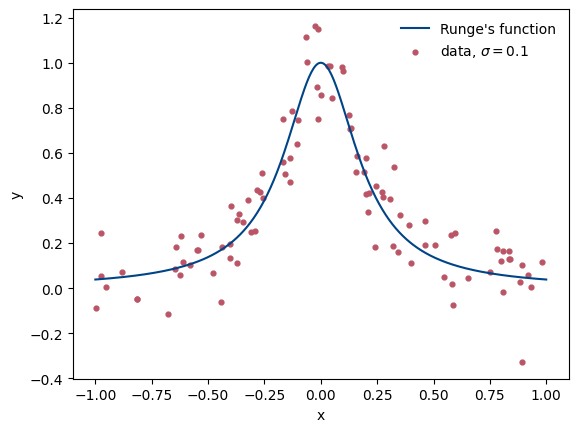

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

### Part a): Ordinary Least Squares (OLS) for the Runge function

We will generate our own data set for the above function $f(x)$ with
$x\in[-1,1]$, using either a uniform distribution or a fixed step size to set up
the array of $x$ values. You should also explore the addition of normally
distributed noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$ to the function; a
noise level of $\sigma\approx0.1$ is a good starting point, but study how your
conclusions depend on it.

**Write your own code** (using for example the pseudoinverse function `pinv`
from `numpy`, or the SVD directly) and perform a standard **ordinary least
squares regression** analysis using polynomials in $x$ up to order 15 or higher.
Explore the dependence on the number of data points and the polynomial degree.

Evaluate the mean squared error (MSE)

$$
\mathrm{MSE}(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
$i$-th sample and $y_i$ is the corresponding true value, then the score $R^2$ is
defined as

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
\qquad
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1}y_i .
$$

Plot the resulting scores (MSE and $R^2$) as functions of the polynomial degree
(here up to polynomial degree 15). Plot also the parameters $\boldsymbol{\thgamma}$
as you increase the order of the polynomial. Comment your results.

Your code has to include a scaling/centering of the data (for example by
subtracting the mean value), and a split of the data in training and test data.
For the splitting you can either write your own code or use for example the
function `train_test_split` provided by **Scikit-Learn** (make sure you have
installed it). **You should present a critical discussion of why and how you
have scaled/ or not scaled the data** (see Section 3.13 of the lecture notes,
the Tuesday session of week 35 and the pertinent notebook for week 35).

It is normal in essentially all Machine Learning studies to split the data in a
training set and a test set (eventually also an additional validation set).
There is no explicit recipe for how much data should be included as training
data and say test data. An accepted rule of thumb is to use approximately $2/3$
to $4/5$ of the data as training data.

You can easily reuse the solutions to your exercises from week 35 (the
analytical derivatives of the cost function, your own OLS code, and the
train/test analysis). See also the lecture slides from weeks 34 and 35 and
Chapter 3 of the lecture notes. On scaling, we recommend reading the following
section from the Scikit-Learn documentation:
<https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html>.
See also Section 3.13 of the lecture notes.

In [2]:
# Your code for part a) here

### Part b): Adding Ridge regression for the Runge function

Write your own code for the Ridge method, as done in the previous part. The
lecture notes from weeks 35 and 36 contain more information, as well as your
exercises from weeks 35 and 36. Feel free to reuse this material.

Perform the same analysis as you did in the previous part but now for different
values of the penalty parameter $\lambda$. Compare and analyze your results with
those obtained in part a) with the OLS method. Study the dependence on
$\lambda$, and connect what you see to the shrinkage of the singular-value modes
discussed in the lectures (Section 3.8 of the lecture notes).

In [3]:
# Your code for part b) here

### Part c): The bias-variance tradeoff and the bootstrap

Our aim here is to study the bias-variance tradeoff by implementing the
**bootstrap** resampling technique. **We will only use the simpler ordinary
least squares here.**

Before you perform an analysis of the bias-variance tradeoff on your test data,
make first a figure similar to Fig. 2.11 of Hastie, Tibshirani and Friedman.
Figure 2.11 of this reference displays only the test and training MSEs. The
test MSE can be used to indicate possible regions of low/high bias and variance.
You will most likely not get an equally smooth curve! You will also need to
increase the polynomial order and play around with the number of data points as
well (see the exercise sets from week 35 and week 36).

With this result we move on to the bias-variance tradeoff analysis. Consider a
data set $\mathcal{L}$ consisting of the data
$\boldsymbol{X}_\mathcal{L}=\{(y_j,\boldsymbol{x}_j),\,j=0,\dots,n-1\}$, and
assume that the true data are generated from a noisy model

$$
\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon},
$$

where $\boldsymbol{\varepsilon}$ is normally distributed with mean zero and
variance $\sigma^2$. In our derivation of the ordinary least squares method we
defined an approximation to the function $f$ in terms of the parameters
$\boldsymbol{\thgamma}$ and the design matrix $\boldsymbol{X}$ which embody our
model, that is $\tilde{\boldsymbol{y}}=\boldsymbol{X}\boldsymbol{\thgamma}$. The
parameters $\boldsymbol{\thgamma}$ are in turn found by optimizing the mean squared
error via the cost function

$$
C(\boldsymbol{X},\boldsymbol{\thgamma}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2
 = \mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right].
$$

Here the expected value $\mathbb{E}$ is the sample value.

Show that you can rewrite this in terms of a term which contains the variance of
the model itself (the so-called variance term), a term which measures the
deviation from the true data and the mean value of the model (the bias term) and
finally the variance of the noise. That is, show that

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
 = \mathrm{Bias}^2[\tilde{y}] + \mathrm{var}[\tilde{y}] + \sigma^2,
$$

with

$$
\mathrm{Bias}^2[\tilde{y}] = \mathbb{E}\left[\left(\boldsymbol{f}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right],
\qquad
\mathrm{var}[\tilde{y}] = \mathbb{E}\left[\left(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right]
 = \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2 .
$$

**Important note:** since the function $f(x)$ is unknown, in order to be able to
evaluate the bias we replace $f(\boldsymbol{x})$ in the expression for the bias
with $\boldsymbol{y}$; discuss what this does to the measured bias term (it
absorbs the noise variance $\sigma^2$). Explain what the three terms mean and
discuss their interprgammations, and state clearly over which randomness the
expectation values are taken.

The answer to this exercise should be included in the theory part of the
report. This derivation is also part of the weekly exercises of week 36, and it
is Eq. (2.52) of Chapter 2 of the lecture notes.

Perform then a bias-variance analysis of the Runge function by studying the MSE
value as function of the complexity of your model, using the **bootstrap**
resampling method to estimate the expectation values over training sets.
Discuss the bias and variance tradeoff as function of your model complexity (the
degree of the polynomial) and the number of data points. You can follow the
code examples in Sections 2.10 and 2.11 of the lecture notes and the Tuesday
notebook of week 36 (`week36tuesday.ipynb`).

In [4]:
# Your code for part c) here

### Part d): Cross-validation as a resampling technique

The aim here is to use another widely popular resampling technique, the
so-called cross-validation method (Section 2.12 of the lecture notes and the
Tuesday session of week 36). For Ridge and Lasso, see also Section 3.14 of the
lecture notes.

Use the $k$-fold cross-validation functionality of **Scikit-Learn** (`KFold`
together with `cross_val_score`, or `cross_validate`) and evaluate again the
MSE function resulting from the test folds, for the OLS analysis of parts a)
and c) as a function of the polynomial degree, and for Ridge regression as a
function of both the polynomial degree and $\lambda$. Try $k=5$ and $k=10$.
Optionally, you can also write your own $k$-fold cross-validation code and
check that it reproduces the Scikit-Learn results when the two use the same
fold assignment (the Tuesday session of week 36 shows how).

Compare the MSE you get from cross-validation with the one you got
from your **bootstrap** code in part c). Do the two methods point to the same
model complexity? Comment and interpret your results. Make sure that any scaling
or other preprocessing that learns from the data is performed *inside* the
cross-validation loop (fitted on the training folds only), and explain why this
matters.

In [5]:
# Your code for part d) here

### Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\thgamma}$ of OLS and Ridge regression with your own gradient descent
code. In this part we focus only on the simplest gradient descent approach with
a fixed learning rate $\gamma$ (see the lectures and exercises of week 37 and
Sections 4.3–4.5 of the lecture notes),

$$
\boldsymbol{\thgamma}_{k+1} = \boldsymbol{\thgamma}_k - \gamma\,\nabla_{\boldsymbol{\thgamma}}C(\boldsymbol{\thgamma}_k).
$$

Compute the gradient of the cost function in two independent ways:

1. **Analytically**, from the expressions you derived in the week-35 exercises,
   that is $\nabla_{\boldsymbol{\thgamma}}C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\thgamma}-\boldsymbol{y})$
   for OLS and the corresponding expression with the extra term
   $2\lambda\boldsymbol{\thgamma}$ for Ridge (check your normalization
   conventions).
2. By **automatic differentiation** (Section 4.14 of the lecture notes), using
   for example **JAX** (`jax.grad`) or **Autograd**. Write the cost function as
   an ordinary Python function of $\boldsymbol{\thgamma}$ and let the library
   produce its gradient.

Verify that the two gradients agree to machine precision for OLS and Ridge, and
use both in your gradient descent code. Discuss briefly why automatic
differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost
function.

Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

The cell below shows the minimal version of the automatic-differentiation check
with JAX (install with `pip install jax jaxlib`). Note the 64-bit switch: JAX
defaults to 32-bit floats, which would hide the "machine precision" agreement.

In [ ]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

degree, lmbda = 5, 1e-1

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree, intercept=False)

n_features = degree  # number of features for polynomial regression
I = np.eye(n_features)  # identity matrix for ridge regression

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y_mean

OLS_closed_form = np.linalg.pinv(X_norm.T @ X_norm) @ X_norm.T @ y_centered
Ridge_closed_form = np.linalg.pinv(X_norm.T @ X_norm + len(y_centered) * lmbda * I) @ X_norm.T @ y_centered 

theta0 = rng.normal(size=X.shape[1])

def cost_ols(thgamma, X, y):
    return jnp.mean((y - X @ thgamma)**2)

def cost_ridge(thgamma, X, y, lmbda):
    return jnp.mean((y - X @ thgamma)**2) + lmbda * jnp.sum(thgamma**2)

# gradients by automatic differentiation (with respect to argument 0 = thgamma)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: gamma < 2 / lambda_max(Hessian)
H_OLS = 2.0 / len(y_centered) * X_norm.T @ X_norm
lam_max_OLS, lam_min_OLS = np.linalg.eigvalsh(H_OLS).max(), np.linalg.eigvalsh(H_OLS).min()
gamma_max_OLS = 2.0 / lam_max_OLS

print("lam_min for OLS  =", round(lam_min_OLS, 4))
print("lam_max for OLS  =", round(lam_max_OLS, 4))

print("gamma_max for OLS  =", round(gamma_max_OLS, 4))
gamma_star_OLS = 2.0 / (lam_max_OLS + lam_min_OLS)
print("gamma* for OLS =", round(gamma_star_OLS, 4))

H_Ridge = 2.0 / len(y_centered) * X_norm.T @ X_norm + 2.0 * lmbda * I
lam_max_Ridge, lam_min_Ridge = np.linalg.eigvalsh(H_Ridge).max(), np.linalg.eigvalsh(H_Ridge).min()
gamma_max_Ridge = 2.0 / lam_max_Ridge

print("lam_min for Ridge =", round(lam_min_Ridge, 4))
print("lam_max for Ridge =", round(lam_max_Ridge, 4))

print("gamma_max for Ridge =", round(gamma_max_Ridge, 4))
gamma_star_Ridge = 2.0 / (lam_max_Ridge + lam_min_Ridge)
print("gamma* for Ridge =", round(gamma_star_Ridge, 4))


# Latex table for the eigenvalues of the Hessian and the largest safe learning rate and optimal learning rate for plain gradient descent
print("\n------------------------------\n")
eigenvalues_table = f""
eigenvalues_table += f"\\begin{{table}}[H]\n"
eigenvalues_table += f"\\centering \n"
eigenvalues_table += f"\\begin{{tabular}}{{|c|c|c|c|c|c|}}\n"
eigenvalues_table += f"\\hline\n"
eigenvalues_table += f"& $\\lambda_{{min}}$ & $\\lambda_{{max}}$ & $\\gamma_{{max}}$ & $\\gamma^*$ & \\kapa \\\\ \n"
eigenvalues_table += f"\\hline\n OLS & {lam_min_OLS:.4f} & {lam_max_OLS:.4f} & {gamma_max_OLS:.4f} & {gamma_star_OLS:.4f} & {lam_max_OLS / lam_min_OLS:.2f} \\\\ \n [5pt] \n"
eigenvalues_table += f"Ridge & {lam_min_Ridge:.4f} & {lam_max_Ridge:.4f} & {gamma_max_Ridge:.4f} & {gamma_star_Ridge:.4f} & {lam_max_Ridge / lam_min_Ridge:.2f} \\\\ \n"
eigenvalues_table += f"\\hline\n"
eigenvalues_table += f"\\end{{tabular}}\n"
eigenvalues_table += f"\\caption{{Eigenvalues of the Hessian and the largest safe learning rate for plain gradient descent.}}\n"
eigenvalues_table += f"\\label{{tab:eigenvalues_learning_rate_gd}}\n"
eigenvalues_table += f"\\end{{table}}"

print(eigenvalues_table)

OLS   max |AD - analytic| = 5.551115123125783e-17
Ridge max |AD - analytic| = 1.1102230246251565e-16
lam_min for OLS  = 0.0109
lam_max for OLS  = 5.6527
gamma_max for OLS  = 0.3538
gamma* for OLS = 0.3531
lam_min for Ridge = 0.2109
lam_max for Ridge = 5.8527
gamma_max for Ridge = 0.3417
gamma* for Ridge = 0.3298

------------------------------

\begin{table}[H]
\centering 
 \begin{tabular}{|c|c|c|c|c|c|}
\hline
& $\lambda_{min}$ & $\lambda_{max}$ & $\gamma_{max}$ & $\gamma^*$ & \kapa \\ 
 \hline
 OLS & 0.0109 & 5.6527 & 0.3538 & 0.3531 & 520.34 \\ 
 [5pt] 
 Ridge & 0.2109 & 5.8527 & 0.3417 & 0.3298 & 27.76 \\ 
 \hline
 \end{tabular}
\caption{Eigenvalues of the Hessian and the largest safe learning rate for plain gradient descent.}
\label{tab:eigenvalues_learning_rate_gd}
\end{table}


In [7]:
beta = 0.9
rho = 0.99
beta1 = 0.9
beta2 = 0.999

def optimiser_step(method, theta, g, state, t, gamma, beta=beta, rho=rho,
                   beta1=beta1, beta2=beta2, eps=1e-8):
    """One update of thgamma from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    # Copilot inline suggested to use the state.get() to initialize the state variables if they don't exist yet
    v = state.get("v", 0.0)
    r = state.get("r", 0.0)
    m = state.get("m", 0.0)

    match method:
        case "plain":                                    # Eq. (4.10)
            return theta - gamma * g, state
        case "momentum":                                 # Eq. (4.28)
            state["v"] = v = beta * v + gamma * g
            return theta - v, state
        case "adagrad":                                  # Eqs. (4.42) and (4.45)
            state["r"] = r = r + g * g
            return theta - gamma * g / np.sqrt(r + eps), state
        case "rmsprop":                                  # Eqs. (4.47) and (4.48)
            state["r"] = r = rho * r + (1 - rho) * g * g
            return theta - gamma * g / np.sqrt(r + eps), state
        case "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
            state["m"] = m = beta1 * m + (1 - beta1) * g
            state["r"] = r = beta2 * r + (1 - beta2) * g * g
            m_hat, r_hat = m / (1 - beta1 ** t), r / (1 - beta2 ** t)
            return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
        case _:
            raise ValueError(f"unknown method {method}")

def gradient_descent(
        X: np.ndarray, 
        y: np.ndarray, 
        method: str = "plain",
        lam: float = 0.0, 
        max_iterations: int = 1e5, 
        learning_rate: float = 0.01,
        tolerance: float = 1e-6, 
        initial_theta: np.ndarray | None = None, 
        theta_hat: np.ndarray | None = None,
        gradient: str = "analytic",
        **kw
    ) -> tuple[np.ndarray, np.ndarray]:
    """
    Perform gradient descent with given method on the given data.

    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)\\
        The normalized design matrix
    y : array-like, shape (n_samples,)\\
        The centered target values
    lam : float, optional\\
        Regularization parameter (lambda) for ridge regression. Default is 0 (OLS).
    method : str, optional\\
        Method for gradient descent optimisation step to choose. Default is "plain".
        (Options are "plain", "momentum", "adagrad", "rmsprop", "adam")
    learning_rate : float, optional\\
        Learning rate (gamma) for gradient descent. Default is 0.01.
    max_iterations : int, optional\\
        Maximum number of iterations for gradient descent. Default is 1e5.
    tolerance : float, optional\\
        Tolerance for convergence. Default is 1e-6.
    initial_theta: np.ndarray, shape (n_features, ) | None, optional\\
        Initial guess for theta. If None, initialized to zeros.
    theta_hat : np.ndarray, shape (n_features, ) | None, optional\\
        Precomputed theta_hat for ridge regression. If None, computed internally.
    gradient : String, optional\\
        The type of gradient to use. Either "analytic" or "autograd". Default is "analytic".
    **kw : dict, optional\\
        Additional keyword arguments for the optimiser_step function.
        Useful for passing parameters like bgamma, rho, bgamma1, bgamma2, eps for specific methods.
        
    Returns:
    --------
    theta_history : np.ndarray, shape (max{# of iterations till convergence, max_iterations}, n_features)\\
        The estimated parameters theta at each gradient descent step.
    distance_history : np.ndarray, shape (max{# of iterations till convergence, max_iterations})\\
            The evaluated distance at each gradient descent step.
                If theta_hat (optional) is given, the distance is evaluated as ||θ - θ̂ ||₂
                otherwise the distance is evaluated as ||θₖ₊₁ - θₖ||₂ 

    (The content of the docstring is generated by Copilot inline suggestions and was reviewed and edited by the user.)
    """

    n_samples, n_features = X.shape

    theta = initial_theta if initial_theta is not None else np.zeros(n_features)
    state = {}

    theta_history = np.array([theta])
    distance_history = np.array([])

    match gradient:
        # choose between analytic gradient or automatic differentiation
        # note: for lam=0 Ridge -> OLS
        case "analytic":
            gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
        case "autograd":
            autograd = jax.grad(cost_ridge)
            gradient_fct = lambda theta: autograd(jnp.asarray(theta), X=jnp.asarray(X), y=jnp.asarray(y), lmbda=lam)
        case _:
            raise ValueError("Parameter gradient (String) has to have the value 'analytic' (analytical gradient for ridge) or 'autograd' (automatic differentiation for ridge)!")

    for t in range(1, int(max_iterations) + 1):
        grad = gradient_fct(theta)

        # update theta (plain gradient descent step)
        theta_new, state_new = optimiser_step(method, theta, grad, state, t, learning_rate, **kw)
        theta_history = np.append(theta_history, theta_new.reshape(1, -1), axis=0)
        
        # approximate the distance, either by 
        # the explicit distance to the closed form result
        # or by the difference θk+1 - θk
        distance = np.linalg.norm(theta_new - theta) if theta_hat is None else np.linalg.norm(theta_new - theta_hat)
        distance_history = np.append(distance_history, distance)

        if distance < tolerance:
            break

        theta = theta_new
        state = state_new

    return theta_history, distance_history

In [8]:
"""gamma_values_OLS = [gamma_max_OLS * factor for factor in [0.5, 0.9, 0.99]]
gamma_values_OLS.append(gamma_star_OLS)
gamma_values_Ridge = [gamma_max_Ridge * factor for factor in [0.1, 0.5, 0.9, 0.99]]
gamma_values_Ridge.append(gamma_star_Ridge)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.333))

distance_history_OLS_arr = []
steps_history_OLS_arr = []
for gamma in gamma_values_OLS:
    theta_history_OLS, distance_history_OLS = gradient_descent(
        X=X_norm,
        y=y_centered,
        lam=0.0,
        learning_rate=gamma,
        method="plain",
        max_iterations=20000,
        tolerance=1e-6,
        initial_theta=theta0,
        gradient="analytic",
        theta_hat=OLS_closed_form
    )
    ax[0].plot(distance_history_OLS, label=f"gamma* = {gamma / gamma_max_OLS:.4f} * gamma_max" if gamma == gamma_star_OLS else f"{gamma / gamma_max_OLS:.4f} * gamma_max")

    distance_history_OLS_arr.append(distance_history_OLS)
    steps_history_OLS_arr.append(len(distance_history_OLS))

ax[0].set_ylabel(r"Distance: $\|\theta_k - \hat{\theta}\|_2$")
ax[0].set_xlabel("Number of Iterations")
ax[0].set_title("Gradient Descent: OLS")
ax[0].legend()
#ax[0].set_xscale("log")
ax[0].set_yscale("log")

distance_history_Ridge_arr = []
steps_history_Ridge_arr = []
for gamma in gamma_values_Ridge:
    theta_history_Ridge, distance_history_Ridge = gradient_descent(
        X=X_norm,
        y=y_centered,
        lam=lmbda,
        learning_rate=gamma,
        method="plain",
        max_iterations=20000,
        tolerance=1e-6,
        initial_theta=theta0,
        gradient="analytic",
        theta_hat=Ridge_closed_form
    )

    ax[1].plot(distance_history_Ridge, label=f"gamma* = {gamma / gamma_max_Ridge:.4f} * gamma_max" if gamma == gamma_star_Ridge else f"{gamma / gamma_max_Ridge:.4f} * gamma_max")
    
    distance_history_Ridge_arr.append(distance_history_Ridge)
    steps_history_Ridge_arr.append(len(distance_history_Ridge))

# ax[1].set_ylabel(r"Tolerance:  $\|\theta_k - \hat{\theta}\|_2$")
ax[1].set_xlabel("Number of Iterations")
ax[1].set_ylabel(r"Distance: $\|\theta_k - \hat{\theta}\|_2$")
ax[1].set_title(rf"Gradient Descent: Ridge ($\lambda={lmbda}$)")
ax[1].legend()
#ax[1].set_xscale("log")
ax[1].set_yscale("log")

plt.tight_layout()

plt.savefig("figures/plain_gradient_descent_OLS_Ridge.pdf", dpi=300, bbox_inches='tight')
plt.show()
"""

<>:28: SyntaxWarning: invalid escape sequence '\|'
<>:28: SyntaxWarning: invalid escape sequence '\|'
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3205555247.py:28: SyntaxWarning: invalid escape sequence '\|'
  ax[0].set_ylabel(r"Distance: $\|\theta_k - \hat{\theta}\|_2$")


'gamma_values_OLS = [gamma_max_OLS * factor for factor in [0.5, 0.9, 0.99]]\ngamma_values_OLS.append(gamma_star_OLS)\ngamma_values_Ridge = [gamma_max_Ridge * factor for factor in [0.1, 0.5, 0.9, 0.99]]\ngamma_values_Ridge.append(gamma_star_Ridge)\n\nfig, ax = plt.subplots(1, 2, figsize=(10, 3.333))\n\ndistance_history_OLS_arr = []\nsteps_history_OLS_arr = []\nfor gamma in gamma_values_OLS:\n    theta_history_OLS, distance_history_OLS = gradient_descent(\n        X=X_norm,\n        y=y_centered,\n        lam=0.0,\n        learning_rate=gamma,\n        method="plain",\n        max_iterations=20000,\n        tolerance=1e-6,\n        initial_theta=theta0,\n        gradient="analytic",\n        theta_hat=OLS_closed_form\n    )\n    ax[0].plot(distance_history_OLS, label=f"gamma* = {gamma / gamma_max_OLS:.4f} * gamma_max" if gamma == gamma_star_OLS else f"{gamma / gamma_max_OLS:.4f} * gamma_max")\n\n    distance_history_OLS_arr.append(distance_history_OLS)\n    steps_history_OLS_arr.append(l

### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

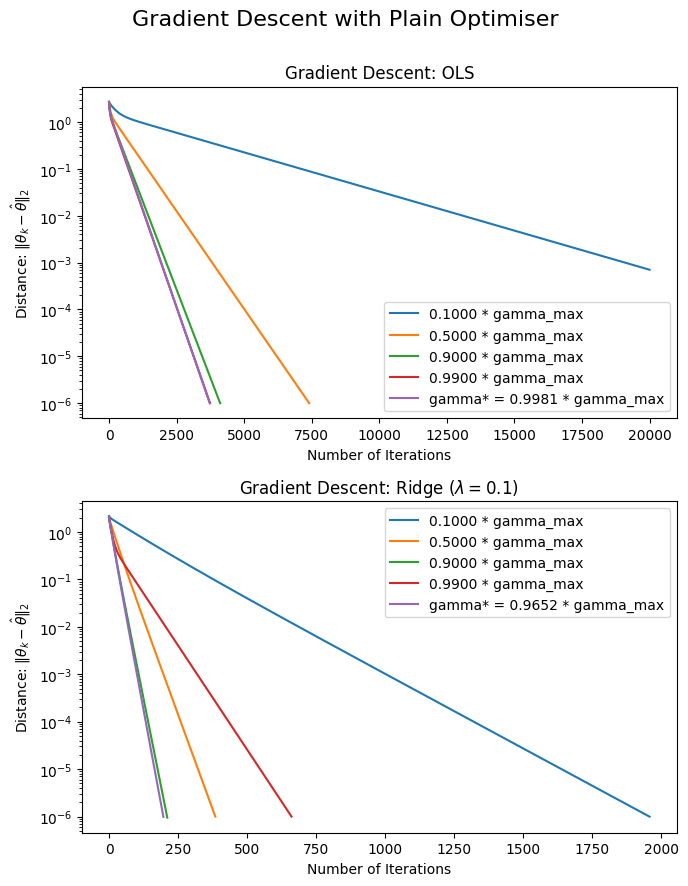

\begin{table}[H]
 \centering 
 \begin{tabular}{c|c|c}
 Method & Learning Rate & Steps to Convergence \\ 
 \hline
 OLS & $0.1000 * \gamma_{\max} = 0.0354$ & did not converge \\ 
 & $0.5000 * \gamma_{\max} = 0.1769$ & 7406 \\ 
 & $0.9000 * \gamma_{\max} = 0.3184$ & 4112 \\ 
 & $0.9900 * \gamma_{\max} = 0.3503$ & 3737 \\ 
 & $0.9981 * \gamma_{\max} = 0.3531$ & 3728 \\ 
\hline
Ridge & $0.1000 * \gamma_{\max} = 0.0342$& 1959 \\ 
 & $0.5000 * \gamma_{\max} = 0.1709$& 386 \\ 
 & $0.9000 * \gamma_{\max} = 0.3075$& 212 \\ 
 & $0.9900 * \gamma_{\max} = 0.3383$& 662 \\ 
 & $0.9652 * \gamma_{\max} = 0.3298$& 198 \\ 
\end{tabular}
\caption{Steps to convergence for different learning rates in plain gradient descent for OLS and Ridge regression.}
\label{tab:steps_to_convergence_plain_GD}
\end{table}


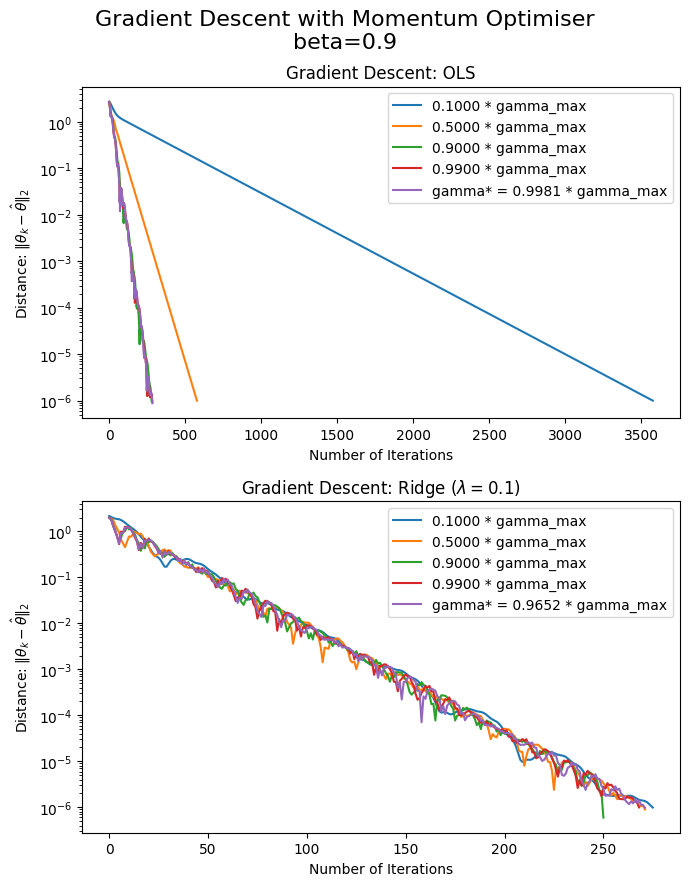

\begin{table}[H]
 \centering 
 \begin{tabular}{c|c|c}
 Method & Learning Rate & Steps to Convergence \\ 
 \hline
 OLS & $0.1000 * \gamma_{\max} = 0.0354$ & 3576 \\ 
 & $0.5000 * \gamma_{\max} = 0.1769$ & 578 \\ 
 & $0.9000 * \gamma_{\max} = 0.3184$ & 280 \\ 
 & $0.9900 * \gamma_{\max} = 0.3503$ & 285 \\ 
 & $0.9981 * \gamma_{\max} = 0.3531$ & 285 \\ 
\hline
Ridge & $0.1000 * \gamma_{\max} = 0.0342$& 276 \\ 
 & $0.5000 * \gamma_{\max} = 0.1709$& 272 \\ 
 & $0.9000 * \gamma_{\max} = 0.3075$& 251 \\ 
 & $0.9900 * \gamma_{\max} = 0.3383$& 269 \\ 
 & $0.9652 * \gamma_{\max} = 0.3298$& 272 \\ 
\end{tabular}
\caption{Steps to convergence for different learning rates in momentum gradient descent for OLS and Ridge regression.}
\label{tab:steps_to_convergence_momentum_GD}
\end{table}


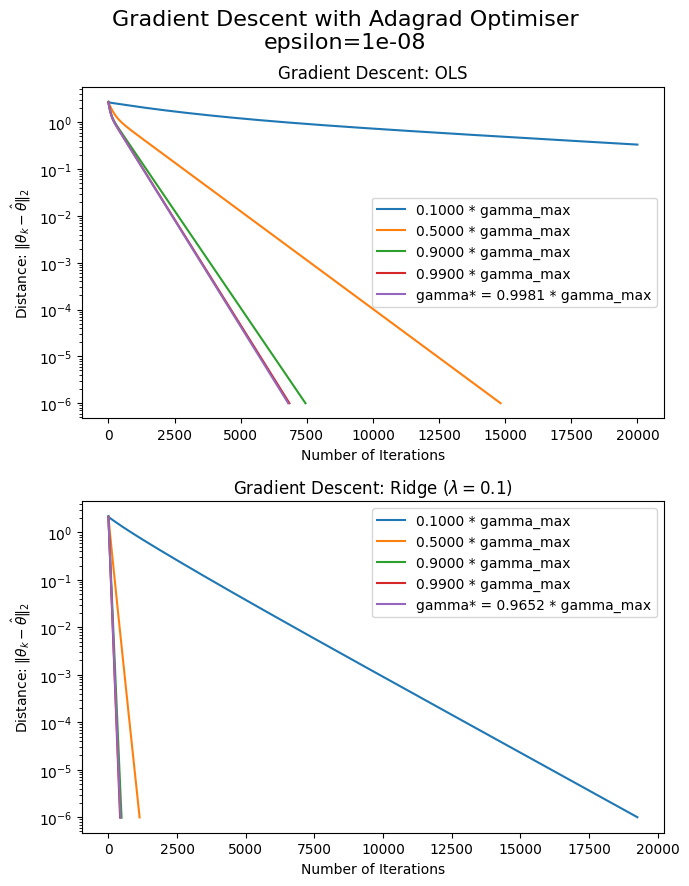

\begin{table}[H]
 \centering 
 \begin{tabular}{c|c|c}
 Method & Learning Rate & Steps to Convergence \\ 
 \hline
 OLS & $0.1000 * \gamma_{\max} = 0.0354$ & did not converge \\ 
 & $0.5000 * \gamma_{\max} = 0.1769$ & 14827 \\ 
 & $0.9000 * \gamma_{\max} = 0.3184$ & 7450 \\ 
 & $0.9900 * \gamma_{\max} = 0.3503$ & 6843 \\ 
 & $0.9981 * \gamma_{\max} = 0.3531$ & 6798 \\ 
\hline
Ridge & $0.1000 * \gamma_{\max} = 0.0342$& 19261 \\ 
 & $0.5000 * \gamma_{\max} = 0.1709$& 1135 \\ 
 & $0.9000 * \gamma_{\max} = 0.3075$& 477 \\ 
 & $0.9900 * \gamma_{\max} = 0.3383$& 424 \\ 
 & $0.9652 * \gamma_{\max} = 0.3298$& 437 \\ 
\end{tabular}
\caption{Steps to convergence for different learning rates in adagrad gradient descent for OLS and Ridge regression.}
\label{tab:steps_to_convergence_adagrad_GD}
\end{table}


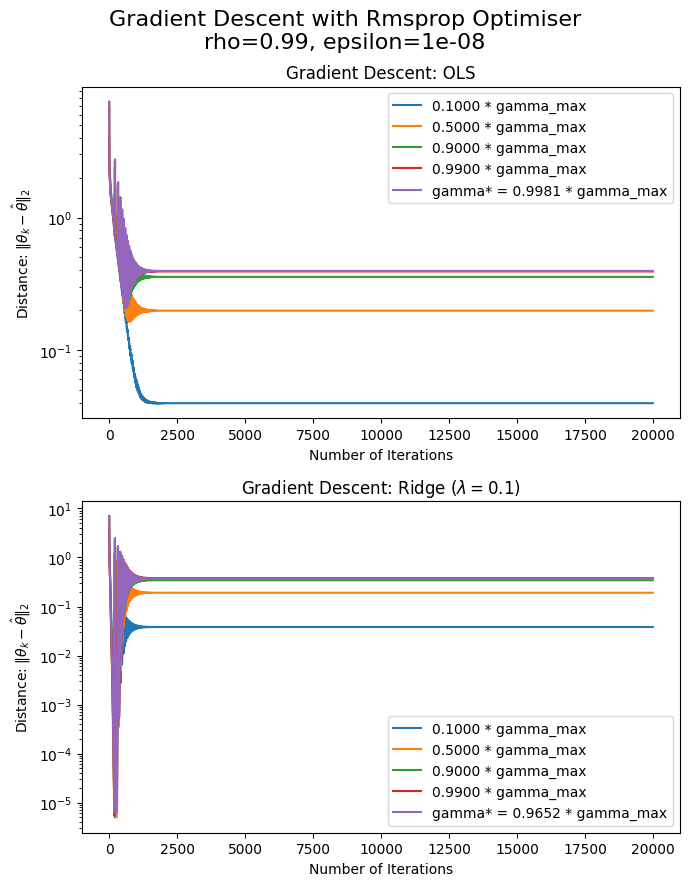

\begin{table}[H]
 \centering 
 \begin{tabular}{c|c|c}
 Method & Learning Rate & Steps to Convergence \\ 
 \hline
 OLS & $0.1000 * \gamma_{\max} = 0.0354$ & did not converge \\ 
 & $0.5000 * \gamma_{\max} = 0.1769$ & did not converge \\ 
 & $0.9000 * \gamma_{\max} = 0.3184$ & did not converge \\ 
 & $0.9900 * \gamma_{\max} = 0.3503$ & did not converge \\ 
 & $0.9981 * \gamma_{\max} = 0.3531$ & did not converge \\ 
\hline
Ridge & $0.1000 * \gamma_{\max} = 0.0342$& did not converge \\ 
 & $0.5000 * \gamma_{\max} = 0.1709$& did not converge \\ 
 & $0.9000 * \gamma_{\max} = 0.3075$& did not converge \\ 
 & $0.9900 * \gamma_{\max} = 0.3383$& did not converge \\ 
 & $0.9652 * \gamma_{\max} = 0.3298$& did not converge \\ 
\end{tabular}
\caption{Steps to convergence for different learning rates in rmsprop gradient descent for OLS and Ridge regression.}
\label{tab:steps_to_convergence_rmsprop_GD}
\end{table}


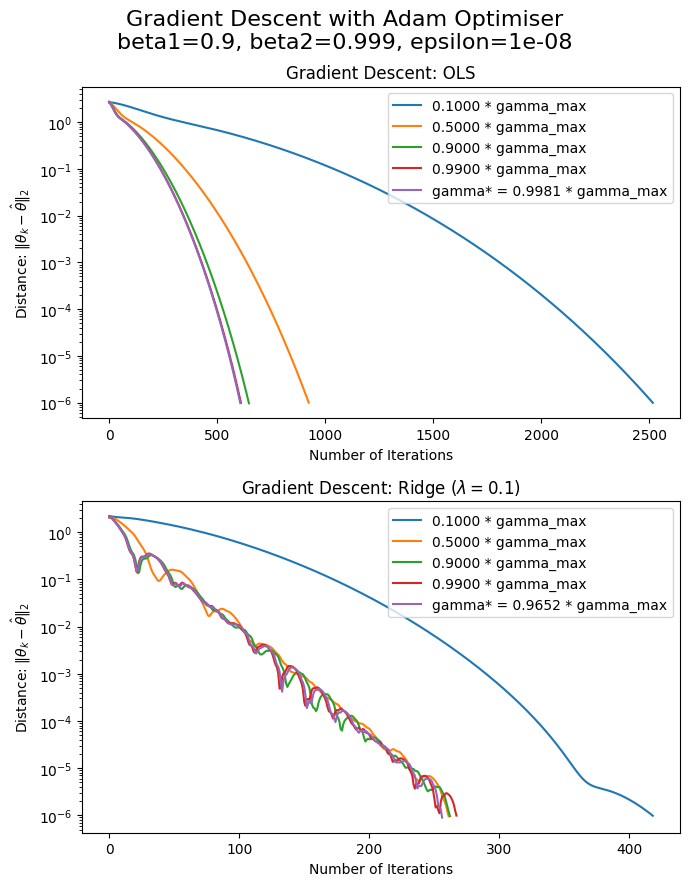

\begin{table}[H]
 \centering 
 \begin{tabular}{c|c|c}
 Method & Learning Rate & Steps to Convergence \\ 
 \hline
 OLS & $0.1000 * \gamma_{\max} = 0.0354$ & 2518 \\ 
 & $0.5000 * \gamma_{\max} = 0.1769$ & 925 \\ 
 & $0.9000 * \gamma_{\max} = 0.3184$ & 648 \\ 
 & $0.9900 * \gamma_{\max} = 0.3503$ & 611 \\ 
 & $0.9981 * \gamma_{\max} = 0.3531$ & 608 \\ 
\hline
Ridge & $0.1000 * \gamma_{\max} = 0.0342$& 419 \\ 
 & $0.5000 * \gamma_{\max} = 0.1709$& 262 \\ 
 & $0.9000 * \gamma_{\max} = 0.3075$& 263 \\ 
 & $0.9900 * \gamma_{\max} = 0.3383$& 268 \\ 
 & $0.9652 * \gamma_{\max} = 0.3298$& 257 \\ 
\end{tabular}
\caption{Steps to convergence for different learning rates in adam gradient descent for OLS and Ridge regression.}
\label{tab:steps_to_convergence_adam_GD}
\end{table}


c:\Users\steff\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:101: RuntimeWarning: overflow encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:101: RuntimeWarning: invalid value encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:101: RuntimeWarning: invalid value encountered in multiply
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:16: RuntimeWarning: overflow encountered in multiply
  return theta - gamma * g, state
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\36209302

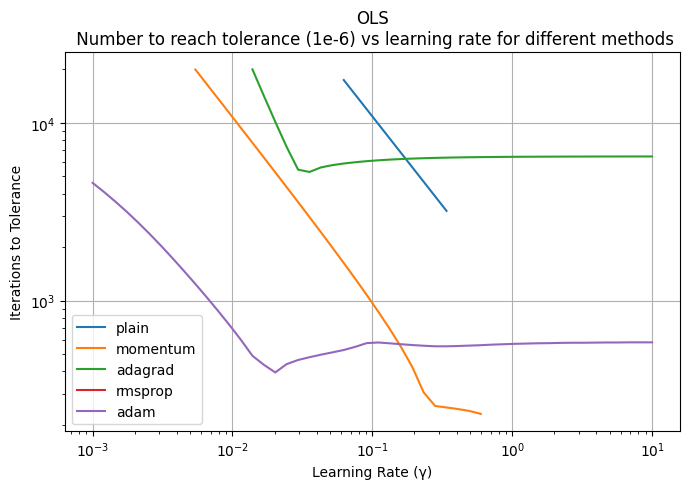

c:\Users\steff\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:101: RuntimeWarning: overflow encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:101: RuntimeWarning: invalid value encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:18: RuntimeWarning: overflow encountered in multiply
  state["v"] = v = beta * v + gamma * g
C:\Users\steff\AppData\Local\Temp\ipykernel_12736\3620930246.py:16: RuntimeWarning: overflow encountered in multiply
  return theta - gamma * g, state


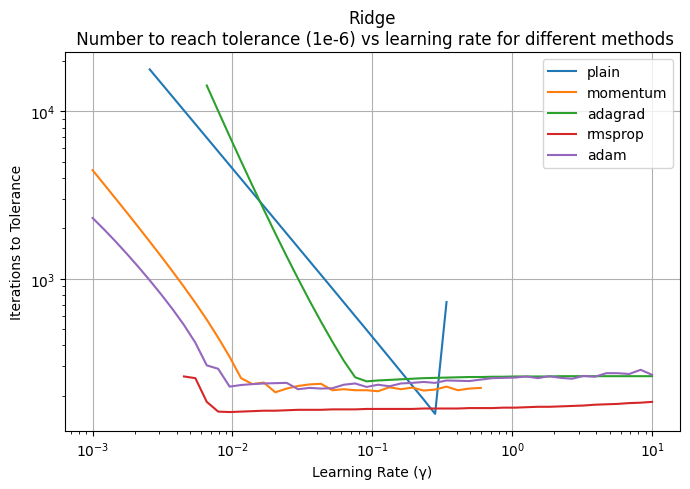

In [12]:

gamma_values_OLS = [gamma_max_OLS * factor for factor in [0.1, 0.5, 0.9, 0.99]]
gamma_values_OLS.append(gamma_star_OLS)
gamma_values_Ridge = [gamma_max_Ridge * factor for factor in [0.1, 0.5, 0.9, 0.99]]
gamma_values_Ridge.append(gamma_star_Ridge)

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
steps_OLS = 2e4
steps_Ridge = 2e4

for method in methods:
    fig, ax = plt.subplots(2, 1, figsize=(7, 9))

    distance_history_OLS_arr = []
    steps_history_OLS_arr = []
    for gamma in gamma_values_OLS:
        theta_history_OLS, distance_history_OLS = gradient_descent(
            X=X_norm,
            y=y_centered,
            lam=0.0,
            method=method,
            learning_rate=gamma,
            max_iterations=steps_OLS,
            tolerance=1e-6,
            initial_theta=theta0,
            gradient="analytic",
            theta_hat=OLS_closed_form
        )

        ax[0].plot(distance_history_OLS, label=f"gamma* = {gamma / gamma_max_OLS:.4f} * gamma_max" if gamma == gamma_star_OLS else f"{gamma / gamma_max_OLS:.4f} * gamma_max")

        distance_history_OLS_arr.append(distance_history_OLS)
        steps_history_OLS_arr.append(len(distance_history_OLS))

    ax[0].set_ylabel(r"Distance: $\|\theta_k - \hat{\theta}\|_2$")
    ax[0].set_xlabel("Number of Iterations")
    ax[0].set_title("Gradient Descent: OLS")
    ax[0].legend()
    #ax[0].set_xscale("log")
    ax[0].set_yscale("log")

    distance_history_Ridge_arr = []
    steps_history_Ridge_arr = []
    for gamma in gamma_values_Ridge:
        theta_history_Ridge, distance_history_Ridge = gradient_descent(
            X=X_norm,
            y=y_centered,
            lam=lmbda,
            learning_rate=gamma,
            max_iterations=steps_Ridge,
            tolerance=1e-6,
            initial_theta=theta0,
            gradient="analytic",
            theta_hat=Ridge_closed_form,
            method=method
        )

        ax[1].plot(distance_history_Ridge, label=f"gamma* = {gamma / gamma_max_Ridge:.4f} * gamma_max" if gamma == gamma_star_Ridge else f"{gamma / gamma_max_Ridge:.4f} * gamma_max")
    
        distance_history_Ridge_arr.append(distance_history_Ridge)
        steps_history_Ridge_arr.append(len(distance_history_Ridge))

    # ax[1].set_ylabel(r"Tolerance:  $\|\theta_k - \hat{\theta}\|_2$")
    ax[1].set_xlabel("Number of Iterations")
    ax[1].set_ylabel(r"Distance: $\|\theta_k - \hat{\theta}\|_2$")
    ax[1].set_title(rf"Gradient Descent: Ridge ($\lambda={lmbda}$)")
    ax[1].legend()
    #ax[1].set_xscale("log")
    ax[1].set_yscale("log")

    title = f"Gradient Descent with {method.capitalize()} Optimiser\n"
    match method:
        case "plain":
            title = title
        case "momentum":
            title = title + f"beta={beta}"
        case "adagrad":
            title = title + f"epsilon={1e-8}"
        case "rmsprop":
            title = title + f"rho={rho}, epsilon={1e-8}"
        case "adam":
            title = title + f"beta1={beta1}, beta2={beta2}, epsilon={1e-8}"
        case _:
            title = title

    plt.suptitle(title, fontsize=16)

    plt.tight_layout()

    plt.savefig(f"figures/{method}_gradient_descent_OLS_Ridge.pdf", dpi=300, bbox_inches='tight')
    plt.show()

    # evaluation table for report
    evaluation_table = f"\\begin{{table}}[H]\n \\centering \n \\begin{{tabular}}{{c|c|c}}\n Method & Learning Rate & Steps to Convergence \\\\ \n \\hline\n" 
    for i, gamma in enumerate(gamma_values_OLS):
        steps = steps_history_OLS_arr[i]
        evaluation_table += f" OLS" if i == 0 else ""
        evaluation_table += f" & ${gamma / gamma_max_OLS:.4f} * \\gamma_{{\\max}} = {gamma:.4f}$ "
        evaluation_table += f"& {steps} \\\\ \n" if steps < steps_OLS else f"& did not converge \\\\ \n"
        
    evaluation_table += "\\hline\n"
    for i, gamma in enumerate(gamma_values_Ridge):
        steps = steps_history_Ridge_arr[i]
        evaluation_table += f"Ridge" if i == 0 else ""
        evaluation_table += f" & ${gamma / gamma_max_Ridge:.4f} * \\gamma_{{\\max}} = {gamma:.4f}$"
        evaluation_table += f"& {steps} \\\\ \n" if steps < steps_OLS else f"& did not converge \\\\ \n"
        
    evaluation_table += f"\\end{{tabular}}\n\\caption{{Steps to convergence for different learning rates in {method} gradient descent for OLS and Ridge regression.}}\n\\label{{tab:steps_to_convergence_{method}_GD}}\n\\end{{table}}"

    print(evaluation_table)
    


#######################################

gamma_values = np.logspace(-3, 1, num=50)

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

iterations_to_tolerance = {method: np.array([]) for method in methods}

for gamma in gamma_values:
    for method in methods:
        theta_hist, dist_hist = gradient_descent(
            X_norm, y_centered, 
            method=method, 
            lam=0.0, 
            learning_rate=gamma,
            max_iterations=int(20000), 
            tolerance=1e-6,
            theta_hat=OLS_closed_form
        )
        iterations_to_tolerance[method] = np.append(iterations_to_tolerance[method], len(dist_hist))

fig, ax = plt.subplots(figsize=(7, 5))
for method in methods:
    divergence_mask = iterations_to_tolerance[method] < 20000  # exclude non-converged runs
    ax.plot(gamma_values[divergence_mask], iterations_to_tolerance[method][divergence_mask], label=method)

# ax.axvline(gamma_max_plain, color='gray', linestyle='--', label=r'$\gamma_{max}$ (plain)')
# ax.axvline(gamma_max_momentum, color='black', linestyle='--', label=r'$\gamma_{max}$ (momentum)')
ax.set_xlabel("Learning Rate (γ)")
ax.set_ylabel("Iterations to Tolerance")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("OLS\n Number to reach tolerance (1e-6) vs learning rate for different methods")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("figures/iterations_to_tolerance_OLS.pdf", dpi=300, bbox_inches='tight')
plt.show()

# same on the ridge regression problem

gamma_values = np.logspace(-3, 1, num=50)

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

iterations_to_tolerance = {method: np.array([]) for method in methods}

for gamma in gamma_values:
    for method in methods:
        theta_hist, dist_hist = gradient_descent(
            X_norm, y_centered, 
            method=method, 
            lam=lmbda, 
            learning_rate=gamma,
            max_iterations=int(20000), 
            tolerance=1e-6,
            theta_hat=Ridge_closed_form
        )
        iterations_to_tolerance[method] = np.append(iterations_to_tolerance[method], len(dist_hist))
            
fig, ax = plt.subplots(figsize=(7, 5))
for method in methods:
    divergence_mask = iterations_to_tolerance[method] < 20000  # exclude non-converged runs
    ax.plot(gamma_values[divergence_mask], iterations_to_tolerance[method][divergence_mask], label=method)

# ax.axvline(gamma_max_plain, color='gray', linestyle='--', label=r'$\gamma_{max}$ (plain)')
# ax.axvline(gamma_max_momentum, color='black', linestyle='--', label=r'$\gamma_{max}$ (momentum)')
ax.set_xlabel("Learning Rate (γ)")
ax.set_ylabel("Iterations to Tolerance")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Ridge\n Number to reach tolerance (1e-6) vs learning rate for different methods")
ax.legend()
ax.grid(True)

plt.tight_layout()

plt.savefig("figures/iterations_to_tolerance_Ridge.pdf", dpi=300, bbox_inches='tight')
plt.show()


### Part g): Writing our own code for Lasso regression

Lasso regression (Section 3.9 of the lecture notes, and the lectures of weeks 35
and 36) represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts e) and f)
to solve the Lasso optimization problem.

The $\ell_1$ penalty $\lambda\|\boldsymbol{\thgamma}\|_1$ is not differentiable
at $\thgamma_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\thgamma|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

In [ ]:
# What does AD say about d|thgamma|/dthgamma at thgamma = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0


### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

In [ ]:
# Your code for part h) here

### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

In [ ]:
# Your code for part i) here

## Background literature

- The lecture notes of the course, in particular Chapter 2 (Sections 2.9–2.12
  on training and test error, the bias-variance tradeoff, the bootstrap and
  cross-validation), Chapter 3 (linear regression, Ridge, Lasso, scaling) and
  Chapter 4 (gradient descent methods and automatic differentiation).
- For a discussion and derivation of the variances and mean squared errors
  using linear regression, see the
  [Lecture notes on ridge regression by Wessel N. van Wieringen](https://arxiv.org/abs/1509.09169).
- The textbook of
  [Trevor Hastie, Robert Tibshirani, Jerome H. Friedman, The Elements of Statistical Learning, Springer](https://www.springer.com/gp/book/9780387848570);
  chapters 3 and 7 are the most relevant ones for the analysis here.
- On automatic differentiation:
  [Baydin et al., Automatic differentiation in machine learning: a survey, JMLR 18 (2018)](https://jmlr.org/papers/v18/17-468.html),
  and the [JAX documentation](https://jax.readthedocs.io).

## Introduction to numerical projects

Here follows a brief recipe and recommendation on how to answer the various
questions when preparing your answers.

- Give a short description of the nature of the problem and the eventual
  numerical methods you have used.
- Describe the algorithm you have used and/or developed. Here you may find it
  convenient to use pseudocoding. In many cases you can describe the algorithm
  in the program itself.
- Include the source code of your program. Comment your program properly. You
  should have the code at your GitHub/GitLab link. You can also place the code
  in an appendix of your report.
- If possible, try to find analytic solutions, or known limits in order to test
  your program when developing the code. In this project the closed-form OLS
  and Ridge solutions are exactly such tests for your gradient descent codes.
- Include your results either in figure form or in a table. Remember to label
  your results. All tables and figures should have relevant captions and labels
  on the axes.
- Try to evaluate the reliability and numerical stability/precision of your
  results. If possible, include a qualitative and/or quantitative discussion of
  the numerical stability, eventual loss of precision etc.
- Try to give an interprgammation of your results in your answers to the
  problems.
- Critique: if possible include your comments and reflections about the
  exercise, whether you felt you learnt something, ideas for improvements and
  other thoughts you've made when solving the exercise. We wish to keep this
  course at the interactive level and your comments can help us improve it.
- Try to establish a practice where you log your work at the computer lab. You
  may find such a logbook very handy at later stages in your work, especially
  when you don't properly remember what a previous test version of your program
  did. Here you could also record the time spent on solving the exercise,
  various algorithms you may have tested or other topics which you feel worthy
  of mentioning.

## Format for electronic delivery of report and programs

The preferred format for the report is a PDF file. You can also use DOC or
postscript formats or an IPython notebook file. As programming language we
prefer that you choose between C/C++, Fortran2008, Julia or Python. The
following prescription should be followed when preparing the report:

- Use Canvas to hand in your projects, log in at
  <https://www.uio.no/english/services/it/education/canvas/> with your normal
  UiO username and password.
- Upload **only** the report file or the link to your GitHub/GitLab or similar
  type of repository! For the source code file(s) you have developed please
  provide us with your link to your GitHub/GitLab or similar domain. The report
  file should include all of your discussions and a list of the codes you have
  developed. Do not include library files which are available at the course
  homepage, unless you have made specific changes to them.
- In your GitHub/GitLab or similar repository, please include a folder which
  contains selected results. These can be in the form of output from your code
  for a selected set of runs and input parameters.

Finally, we encourage you to collaborate. Optimal working groups consist of 2–3
students. You can then hand in a common report.

## Software and needed installations

If you have Python installed (we recommend Python 3) and you feel pretty
familiar with installing different packages, we recommend that you install the
following Python packages via `pip` as

    pip install numpy scipy matplotlib ipython jupyter scikit-learn pandas jax jaxlib

(`autograd` is a lighter alternative to JAX for the automatic differentiation in
parts e)–g)). For Python 3, replace `pip` with `pip3` where needed.

For OSX users we recommend also, after having installed Xcode, to install
`brew`. Brew allows for a seamless installation of additional software via for
example `brew install python3`. For Linux users, with its variety of
distributions like for example the widely popular Ubuntu distribution, you can
use `pip` as well and simply install Python as `sudo apt-get install python3`
etc.

If you don't want to install various Python packages with their dependencies
separately, we recommend [Anaconda](https://docs.anaconda.com/), an open source
distribution of the Python and R programming languages for large-scale data
processing, predictive analytics, and scientific computing, that aims to
simplify package management and deployment. Package versions are managed by the
package management system `conda`.

Popular software packages written in Python for ML are
[Scikit-learn](http://scikit-learn.org/stable/), [JAX](https://jax.readthedocs.io),
[TensorFlow](https://www.tensorflow.org/), [PyTorch](http://pytorch.org/) and
[Keras](https://keras.io/). These are all freely available at their respective
GitHub sites. They encompass communities of developers in the thousands or more,
and the number of code developers and contributors keeps increasing.